# Applied Machine Learning Project

## Fire/Smoke Detection with Multi-Sensor IoT Data

**Goal:** Train a machine-learning model that reduces false alarms in IoT-based fire
detection, using the public *Smoke Detection Dataset* (Kaggle `deepcontractor/smoke-detection-dataset`).

**Future Coal:** The trained model will become a *tool* the P6 agent (and P7's incident-fusion copilot) can
call on a live sensor stream to decide whether an alarm should be escalated or dismissed.

**Methodology:** rules-first → ML upgrade. We start with a simple threshold rule on
temperature + TVOC as an interpretable baseline, then train a Random Forest / Gradient
Boosting classifier and (optionally) an Isolation Forest anomaly detector for novel fire
signatures. All decisions are made on a stratified train/test split to preserve the
71.5/28.5 alarm/no-alarm balance.

**Source:** [Kaggle](https://www.kaggle.com/datasets/deepcontractor/smoke-detection-dataset)

**Dataset mirror (shipped with submission):** `data/raw/smoke_detection_iot.csv`

## Notebook outline

1. **Task 1 — Define the problem**
2. **Task 2 — Load and inspect the dataset**
3. **Task 3 — Data preparation and preprocessing**
4. **Task 4 — Select and train a model**
5. **Task 5 — Evaluate model performance**
6. **Task 6 — Notebook summary**

A separate PDF deliverable, `Machine_Learning_Analysis_Report.pdf`, covers Task 7.

## Task 1 — Define the problem and choose the dataset

**Problem type:** Supervised **binary classification** — predict the `Fire Alarm`
column (0 = no fire detected, 1 = fire detected) from 13 sensor readings.

**Business framing:** IoT smoke detectors generate a high volume of false alarms
(cooking steam, dust, humidity spikes). Each false alarm carries an operational cost
(dispatch, customer trust, monitoring fees). We need a model that maintains **high
recall** on real fire signatures while raising **precision** so operators trust the
alarm channel again. This is the core value proposition of the AI feature we will
ship to the company.

**Why this dataset:**
- Public, non-synthetic, real IoT sensor prototype — meets the rubric constraint
  that the dataset be publicly available and *not* AI-generated.
- Not the same dataset used in Projects 1 or 2 (those were synthetic surveillance
  / access logs from the capstone bundle).
- 62,630 rows × 13 features + 1 target — large enough for train/validation/test
  splits and a real comparison, small enough to train in seconds on a laptop.
- 71.5% / 28.5% class balance (alarm / no-alarm) — moderately imbalanced; we will 
  use a stratified split and report precision/recall/F1, not just accuracy.

**Source:** [Kaggle — Smoke Detection Dataset](https://www.kaggle.com/datasets/deepcontractor/smoke-detection-dataset)


## Task 2 — Load and inspect the dataset

In [43]:
# Install the required packages
import importlib
import subprocess
import sys

def install_libs() -> None:
    """
    Installs common data science libraries if missing.
    Libraries: scipy, pandas, numpy, matplotlib, seaborn
    """
    required = {
        "pandas": "pandas",
        "numpy": "numpy",
        "sklearn": "scikit-learn",
        "matplotlib": "matplotlib",
    }

    to_install = []

    for module, pkg in required.items():
        try:
            importlib.import_module(module)
        except ImportError:
            to_install.append(pkg)

    if to_install:
        # Install quietly, without upgrade
        cmd = [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--no-cache-dir",
        ] + to_install

        subprocess.run(cmd, check=True)
    print("All required libraries are installed.")

install_libs()

All required libraries are installed.


In [90]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/smoke_detection_iot.csv"
TARGET = "Fire Alarm"
RANDOM_STATE = 42

# First column is the Kaggle default index — drop it explicitly.
df = pd.read_csv(DATA_PATH, index_col=0)
df.head()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


* Note:
  - Consecutive rows are UTC 1654733331, 1654733332, 1654733333... — one second apart, with Temperature drifting 20.000 → 20.015 → 20.029. These aren't independent samples; they're a continuous recording from one sensor prototype. The Fire Alarm state runs in long contiguous blocks (the device sat in a fire condition for minutes at a time).

In [91]:
print(f"Shape: {df.shape}\n")
print("Dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nTarget distribution (Fire Alarm):")
print(df[TARGET].value_counts(normalize=True).round(4))

Shape: (62630, 15)

Dtypes:
UTC                 int64
Temperature[C]    float64
Humidity[%]       float64
TVOC[ppb]           int64
eCO2[ppm]           int64
Raw H2              int64
Raw Ethanol         int64
Pressure[hPa]     float64
PM1.0             float64
PM2.5             float64
NC0.5             float64
NC1.0             float64
NC2.5             float64
CNT                 int64
Fire Alarm          int64
dtype: object

Missing values per column:
UTC               0
Temperature[C]    0
Humidity[%]       0
TVOC[ppb]         0
eCO2[ppm]         0
Raw H2            0
Raw Ethanol       0
Pressure[hPa]     0
PM1.0             0
PM2.5             0
NC0.5             0
NC1.0             0
NC2.5             0
CNT               0
Fire Alarm        0
dtype: int64

Target distribution (Fire Alarm):
Fire Alarm
1    0.7146
0    0.2854
Name: proportion, dtype: float64


In [92]:
df.describe()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


**Data-quality notes (Task 2 observation):**

- No missing values in any column — imputation is not required.
- All features are numeric (float64 / int64); no categorical encoding needed
  for the raw features.
- `UTC` is a Unix timestamp in seconds; will be engineered into a time-of-day
  feature in Task 3 (avoid leaking the raw timestamp into the model).
- `CNT` is a sample count; included in the source but not a true sensor reading.
  We will keep it for the first model pass and then drop it after seeing
  feature importance.
- Class imbalance: 71.5% alarm vs 28.5% no-alarm. A naïve accuracy baseline
  that always predicts "alarm" would score 0.715 — we will beat this with
  proper precision/recall.
- Temperature ranges from −22°C to 60°C — wide but physically plausible for a sensor over a long measurement window.

## Task 3 — Data preparation and preprocessing

Steps (each with a short *why*):

1. **Engineer a time-of-day feature** from `UTC`. Fires during sleep hours
   carry different operational meaning than lunch-time cooking peaks. We
   convert to local hour-of-day (sin/cos encoded for cyclicality).
2. **Drop the raw `UTC` and `CNT` columns.** `UTC` is now represented by
   engineered features; `CNT` is metadata about the device firmware, not a
   physical signal. Both are leakage-/artifact risks.
3. **Group-aware, stratified 80/20 split.** The dataset is a continuous
   recording from one sensor prototype (~1 row per second) and the
   `Fire Alarm` label runs in 11 contiguous blocks, two of them ~6 hours
   long. A plain random split interleaves adjacent seconds across the
   boundary, and tree models memorize the near-duplicate readings and
   inflate F1 to ~0.9998. We assign each row a `block_id` (= one
   contiguous run of identical labels) and use `StratifiedGroupKFold` so
   **whole blocks** land on one side of the split *and* both sides get a
   mix of alarm and no-alarm blocks. The fold whose test set is closest
   to 20% of rows becomes the holdout.
4. **Standardise numeric features** (zero mean, unit variance) using
   `StandardScaler` fit on the train set only. The baseline rule needs no
   scaling; the tree-based models do not need it either — but we standardise
   anyway because Task 4 also runs an Isolation Forest that is
   distance-based and benefits from it.

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Engineer time-of-day from UTC (cyclical encoding).
df["hour"] = pd.to_datetime(df["UTC"], unit="s").dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

hint = '''
The point is to convert a clock (0–23 hours) into a format a model can use without being lied to by the math.

The problem with raw hour

If I just added df["hour"] as a feature, hour 0 (midnight) and hour 23 (11 PM) would look like 23 units apart to a
tree or linear model — but in real life they're only 1 hour apart. The model would learn that going from 0 → 23 is a
big jump, which is the opposite of the truth. Same problem at 6 AM vs 7 AM: numerically they're 1 apart (correct) but
23 AM vs 0 AM (midnight wrapping) would look like a 23-unit cliff. A model treats the clock as if it were on a number
line, not a loop.

What sin/cos does

sin(2π·h/24) and cos(2π·h/24) place each hour on the unit circle:

- sin(0) = 0, cos(0) = 1 → midnight sits at coordinate (1, 0)
- sin(2π·6/24) = 1, cos(...) = 0 → 6 AM sits at (0, 1)
- sin(2π·12/24) = 0, cos(...) = -1 → noon sits at (−1, 0)
- sin(2π·23/24) ≈ -0.26, cos(...) ≈ 0.97 → 11 PM sits at (0.97, −0.26), right next door to midnight on the circle

So the cyclical encoding puts 23:00 and 00:00 close together in feature space, and 00:00 and 12:00 on opposite sides,
exactly mirroring how a clock works.

Why both sin and cos

One coordinate isn't enough: sin alone can't distinguish between two hours that land at the same Y-value (e.g. 6 AM
and 6 PM both give sin = 1, 0 — actually 6 AM gives sin=1, 6 PM gives sin=−1, so just sin does distinguish those). The
general point: with both (x, y) on the unit circle, every hour has a unique 2-D coordinate. Without cos, you'd lose
the ability to disambiguate hours on the lower half of the circle.
'''


In [94]:
# Sample of engineered time features
df[["hour", "hour_sin", "hour_cos"]].sample(10, random_state=RANDOM_STATE)

,hour,hour_sin,hour_cos
31120,9,0.707107,-0.707107
49054,14,-0.500000,-0.866025
55910,19,-0.965926,0.258819
33802,10,0.500000,-0.866025
9683,2,0.500000,0.866025
30559,9,0.707107,-0.707107
25558,8,0.866025,-0.500000
5692,1,0.258819,0.965926
7339,2,0.500000,0.866025
62290,14,-0.500000,-0.866025


![image.avif](https://user14030.na.imgto.link/public/20260618/image.avif)

In [95]:
# Sort chronologically. Rows are a continuous recording from one sensor
# prototype. The row-to-row gap is 1 second for 62,625 of 62,629 rows;
# there are only 4 gaps > 60s. Those gaps are the true independence boundary
# — everything between two gaps is one continuous recording (a "session"),
# and adjacent seconds within a session are near-duplicate readings with
# a constant Fire Alarm label. A plain random split interleaves those
# adjacent seconds across the boundary, so tree models memorize the
# near-duplicates and inflate F1 to ~0.9998. The leak-proof unit is the
# *session*, not the row.
df = df.sort_values("UTC").reset_index(drop=True)

# session_id: one per continuous recording. A new session starts whenever
# the UTC gap to the previous row exceeds 60 s. This yields 5 raw sessions.
utc = df["UTC"].to_numpy()
session_id = np.empty(len(df), dtype=int)
session_id[0] = 0
for i in range(1, len(df)):
    session_id[i] = session_id[i - 1] + (1 if (utc[i] - utc[i - 1]) > 60 else 0)

# Sessions 1 and 2 (raw) are the SAME fire event recorded twice — verified
# identical row count (24,994), duration (416 min), and every gas/particulate
# feature mean, with sorted-TVOC correlation = 1.0000; only Temperature and
# hour-of-day differ (the room cooled between the two runs). Keeping them as
# separate CV folds would let the model train on one and "generalize" to its
# twin — still leakage. Collapse them into one CV unit so every LOSO fold is
# genuinely independent.
session_id = np.where(session_id == 2, 1, session_id)
df["session_id"] = session_id

# 2. Drop raw timestamp + sample-count; `hour` is now represented by sin/cos.
df = df.drop(columns=["UTC", "hour", "CNT"])

y = df[TARGET]
X = df.drop(columns=[TARGET, "session_id"])
groups = df["session_id"]

# 3. No single train/test split. The recording sessions are extremely
#    unbalanced in size (one duplicated fire = ~80% of all rows, all alarm),
#    so there is NO leak-free split that preserves the 71/29 class balance:
#    any whole-session holdout is either ~100% alarm or ~0% alarm. Instead
#    we use Leave-One-Session-Out (LOSO) CV — 4 folds, one per independent
#    session — so every metric is on a session the model has never seen.
#    Because most sessions are mixed (alarm + no-alarm rows), each fold
#    reports both sensitivity (recall on its alarm rows) and specificity
#    (TNR on its no-alarm rows) rather than one summary F1.

# 4. Standardise features per LOSO fold inside a Pipeline so each fold scales
#    on its own training sessions only (no leakage of test-session
#    statistics). Trees don't need scaling; the distance-based models do,
#    so we use a Pipeline everywhere for consistency.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# A reusable scaler-pipeline factory.
def scaled(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

print("Sessions (after collapsing the duplicated fire 1+2 into one unit):")
print(df.groupby("session_id")[TARGET]
        .agg(rows="size", alarm_rate="mean")
        .round(3).to_string())
print(f"\nTotal rows: {len(df)} | independent CV units: {groups.nunique()}")

Sessions (after collapsing the duplicated fire 1+2 into one unit):
             rows  alarm_rate
session_id                   
0            5744       0.000
1           49988       0.873
3            1154       0.971
4            5744       0.000

Total rows: 62630 | independent CV units: 4


## Task 4 — Select and train a machine learning model

We train four models. Each is wrapped in a `StandardScaler` pipeline so the
per-LOSO-fold scaling in Task 5 is consistent across models (trees are
scale-invariant and ignore it; the distance-based Isolation Forest needs it).

1. **Baseline rule** — `Fire Alarm = 1 if Temperature[C] > T_thresh AND TVOC[ppb] > V_thresh`.
   Thresholds are picked from a coarse grid that maximises F1 on the full
   dataset. This is the "rules-first" anchor and a fully interpretable
   reference point.
2. **Random Forest classifier** — robust, gives feature importances, handles
   multicollinearity between PM1.0/PM2.5 and the NC* counts.
3. **Gradient Boosting classifier** — usually wins on tabular data; we use
   scikit-learn's `GradientBoostingClassifier`.
4. **Logistic Regression** — linear baseline for comparison.

For each supervised model we report **Leave-One-Session-Out CV F1** (mean
across the 4 independent sessions, with the duplicate fire sessions 1+2 kept
as one unit). The CV score is the honest cross-session generalization
estimate; the per-session breakdown follows in Task 5. We also fit an
**Isolation Forest** as an *unsupervised* anomaly detector, evaluated under
the same LOSO protocol.

In [96]:
# --- Model 1: baseline threshold rule ---

# Pick thresholds on a coarse grid to maximise F1 on the full dataset.
# (There is no train/test split now — evaluation is LOSO in Task 5, which
# applies these same fixed thresholds per held-out session. Tuning on the
# full set makes the rule mildly optimistic, but it is a weak baseline and
# the comparison protocol is identical to the ML models.)

from sklearn.metrics import f1_score

best = {"thresh_t": None, "thresh_v": None, "f1": -1}

for t in np.arange(15, 45, 2):
    for v in np.arange(0, 3200, 50):
        preds = ((X["Temperature[C]"] > t) & (X["TVOC[ppb]"] > v)).astype(int)
        f1 = f1_score(y, preds)
        if f1 > best["f1"]:
            best = {"thresh_t": t, "thresh_v": v, "f1": f1}
print(f"Best rule (full-data F1):\nTemperature: {best['thresh_t']},\nTVOC: {best['thresh_v']},\nF1: {best['f1']:0.4f}")

Best rule (full-data F1):
Temperature: 15,
TVOC: 200,
F1: 0.6928


In [97]:
# --- Model 2: Random Forest ---
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut

# Random Forest inside the scaler pipeline (trees ignore scaling; this keeps
# the LOSO fold-scoping identical across all models and prevents any
# held-out-session statistics leaking into a fold).
rf = scaled(RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    min_samples_split=10,
    n_jobs=-1,
    random_state=RANDOM_STATE
))

# Leave-One-Session-Out: 5 folds, each holds out one whole recording session.
# Every test fold is a session the model has never seen, so the score is a
# true cross-session generalization estimate, not an in-session
# interpolation. We report the mean F1 across folds plus the spread.
logo = LeaveOneGroupOut()
rf_cv_scores = cross_val_score(
    rf, X, y, cv=logo, scoring="f1", groups=groups, n_jobs=-1
)
print(f"Random Forest LOSO F1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# cross_val_score clones the estimator, so it leaves `rf` unfitted. The CV
# above is the generalization estimate; the fit below trains on ALL sessions
# so Task 5 can score each held-out session with one consistent model.
rf.fit(X, y)

Random Forest LOSO F1: 0.0003 (+/- 0.0004)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Temperature[C]','Humidity[%]','TVOC[ppb]',...,'NC2.5','hour_sin', 'hour_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [98]:
# --- Model 3: Gradient Boosting ---
gb = scaled(GradientBoostingClassifier(random_state=RANDOM_STATE))

gb_cv_scores = cross_val_score(
    gb, X, y, cv=logo, scoring="f1", groups=groups, n_jobs=-1
)
print(f"Gradient Boosting LOSO F1: {gb_cv_scores.mean():.4f} (+/- {gb_cv_scores.std():.4f})")

# See note on the RF cell: CV clones the estimator, so fit the final model on
# all sessions for the per-session evaluation below.
gb.fit(X, y)

Gradient Boosting LOSO F1: 0.1045 (+/- 0.1805)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Temperature[C]','Humidity[%]','TVOC[ppb]',...,'NC2.5','hour_sin', 'hour_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [99]:
# --- Model 4: Logistic Regression ---
from sklearn.linear_model import LogisticRegression

# Reuse the `scaled()` factory so LR sits behind StandardScaler with the same
# per-fold scoping as the tree models.
lr = scaled(LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=10_000,
))

lr_cv_scores = cross_val_score(
    lr, X, y, cv=logo, scoring="f1", groups=groups, n_jobs=-1
)
print(f"Logistic Regression LOSO F1: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

lr.fit(X, y)

Logistic Regression LOSO F1: 0.0541 (+/- 0.0936)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Temperature[C]','Humidity[%]','TVOC[ppb]',...,'NC2.5','hour_sin', 'hour_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
# Isolation Forest is evaluated inside the LOSO loop in the Task 5 cell below
# (`loso_iforest`), so it gets the same cross-session protocol as the
# supervised models — trained per-fold on the scaled training sessions only.
# Nothing to fit here standalone; this cell just keeps the model's intent on
# the record.

In [ ]:
# (Isolation Forest predictions happen inside `loso_iforest` in the Task 5 cell.)
# Summary: see `results_df` for the Isolation Forest rows under LOSO.

* Isolation Forest (Unsupervised Baseline):

We included an unsupervised baseline using Isolation Forest to explore anomaly
detection without relying on class labels. Under the same LOSO protocol as the
supervised models (trained per-fold on the other sessions' scaled features),
it learns each training set's distribution with `contamination=0.05` and flags
deviations as anomalies; predictions are converted from Isolation Forest's
native output (1 = normal, -1 = anomaly) to our binary format (0 = normal,
1 = alarm).

As the `results_df` table shows, its behaviour across held-out sessions is
*bimodal and useless for operations*: it almost never fires on the alarm rows
of most unseen sessions (sensitivity 0.0 on sessions 0, 1 and 4 — it misses
real fires), yet on session 3 it fires on every row (sensitivity 1.0 *and*
specificity 0.0 — the high F1 there is vacuous, since it simply predicts
"alarm" for the whole 97%-alarm session). This confirms that unsupervised
anomaly detection struggles here: the alarm class does not form a clean
statistical outlier in feature space, and a model with no access to the alarm
label cannot learn a transferable fire signature.

## Task 5 — Evaluate model performance

We evaluate with **Leave-One-Session-Out (LOSO) cross-validation**. For each
of the 4 independent recording sessions we train on the other three and
score the held-out one — so every metric is on a session the model has
never seen, with the duplicate fire sessions (1+2) kept together as one
unit so no model trains on a recording and "generalizes" to its twin.

Because the sessions are mixed and severely size-imbalanced, a single
accuracy or F1 hides the real trade-off. Each fold reports **both**:

- **Sensitivity** — recall on that session's alarm rows (do we catch real fires?).
- **Specificity** — true-negative rate on that session's no-alarm rows
  (do we stay quiet? — the false-alarm-reduction goal).

This is the operationally honest picture. The earlier ~0.9998 F1 from a
random split was an artifact of interleaving adjacent seconds across the
train/test boundary; LOSO removes it, and the resulting numbers show how
much the models actually transfer across recording sessions.

In [100]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.base import clone
import matplotlib.pyplot as plt

# Leave-One-Session-Out evaluation. For each independent session we train on
# the other three and score the held-out one. Because the dataset's sessions
# are mixed (alarm + no-alarm rows) and severely unbalanced, no single
# accuracy/F1 captures the story — so each fold reports BOTH:
#   sensitivity  = recall on that session's alarm rows   (do we catch real fires?)
#   specificity  = TNR on that session's no-alarm rows    (do we stay quiet?)
# These are the operationally meaningful metrics for a false-alarm-reduction
# system: high sensitivity with high specificity is the goal.
logo = LeaveOneGroupOut()

def loso_table(model, name):
    """Run LOSO on `model` and return one row per session."""
    out = []
    for train_idx, test_idx in logo.split(X, y, groups=groups):
        sid = int(groups.iloc[test_idx[0]])
        m = clone(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = m.predict(X.iloc[test_idx])
        yt = y.iloc[test_idx]
        cm = confusion_matrix(yt, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0   # recall on alarm rows
        spec = tn / (tn + fp) if (tn + fp) else 0.0   # TNR on no-alarm rows
        out.append({
            "session": sid,
            "rows": len(test_idx),
            "alarm_rate": round(float(yt.mean()), 3),
            "model": name,
            "sensitivity": round(sens, 4),
            "specificity": round(spec, 4),
            "accuracy": round(accuracy_score(yt, preds), 4),
            "f1": round(f1_score(yt, preds, zero_division=0), 4),
        })
    return out

# Baseline threshold rule under the same LOSO loop. `best` thresholds were
# tuned on the full dataset in the rule cell above, so this is mildly
# optimistic — but the rule is so weak it won't matter, and keeping it on
# the same evaluation protocol is the fair comparison.
def loso_rule():
    out = []
    for train_idx, test_idx in logo.split(X, y, groups=groups):
        sid = int(groups.iloc[test_idx[0]])
        Xt = X.iloc[test_idx]
        yt = y.iloc[test_idx]
        preds = (
            (Xt["Temperature[C]"] > best["thresh_t"]) &
            (Xt["TVOC[ppb]"] > best["thresh_v"])
        ).astype(int).to_numpy()
        cm = confusion_matrix(yt, preds, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
        out.append({
            "session": sid, "rows": len(test_idx), "alarm_rate": round(float(yt.mean()), 3),
            "model": "Baseline rule",
            "sensitivity": round(tp / (tp + fn) if (tp + fn) else 0.0, 4),
            "specificity": round(tn / (tn + fp) if (tn + fp) else 0.0, 4),
            "accuracy": round(accuracy_score(yt, preds), 4),
            "f1": round(f1_score(yt, preds, zero_division=0), 4),
        })
    return out

# Isolation Forest (unsupervised) under LOSO, scaled per-fold inside a Pipeline.
from sklearn.ensemble import IsolationForest

def loso_iforest():
    out = []
    for train_idx, test_idx in logo.split(X, y, groups=groups):
        sid = int(groups.iloc[test_idx[0]])
        yt = y.iloc[test_idx]
        pipe = scaled(IsolationForest(
            n_estimators=200, contamination=0.05,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
        pipe.fit(X.iloc[train_idx])
        raw = pipe.predict(X.iloc[test_idx])      # +1 inlier / -1 outlier
        preds = np.where(raw == -1, 1, 0)
        cm = confusion_matrix(yt, preds, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
        out.append({
            "session": sid, "rows": len(test_idx), "alarm_rate": round(float(yt.mean()), 3),
            "model": "Isolation Forest",
            "sensitivity": round(tp / (tp + fn) if (tp + fn) else 0.0, 4),
            "specificity": round(tn / (tn + fp) if (tn + fp) else 0.0, 4),
            "accuracy": round(accuracy_score(yt, preds), 4),
            "f1": round(f1_score(yt, preds, zero_division=0), 4),
        })
    return out

results_df = pd.DataFrame(
    loso_table(rf, "Random Forest")
    + loso_table(gb, "Gradient Boosting")
    + loso_table(lr, "Logistic Regression")
    + loso_rule()
    + loso_iforest()
)
# session description for readability
session_desc = {0: "no-alarm", 1: "fire (1+2)", 3: "short fire", 4: "no-alarm"}
results_df["session_type"] = results_df["session"].map(session_desc)
cols = ["model", "session", "session_type", "rows", "alarm_rate",
        "sensitivity", "specificity", "accuracy", "f1"]
results_df = results_df[cols].sort_values(["model", "session"]).reset_index(drop=True)
results_df

,model,session,session_type,rows,alarm_rate,sensitivity,specificity,accuracy,f1
0,Baseline rule,0,no-alarm,5744,0.000,0.0000,0.6672,0.6670,0.0000
1,Baseline rule,1,fire (1+2),49988,0.873,0.5659,0.9986,0.6209,0.7227
2,Baseline rule,3,short fire,1154,0.971,0.4255,1.0000,0.4419,0.5970
3,Baseline rule,4,no-alarm,5744,0.000,0.0000,0.8574,0.8571,0.0000
4,Gradient Boosting,0,no-alarm,5744,0.000,0.0000,0.6799,0.6797,0.0000
5,Gradient Boosting,1,fire (1+2),49988,0.873,0.2637,0.9976,0.3570,0.4172
6,Gradient Boosting,3,short fire,1154,0.971,0.0000,1.0000,0.0286,0.0000
7,Gradient Boosting,4,no-alarm,5744,0.000,1.0000,0.0000,0.0003,0.0007
8,Isolation Forest,0,no-alarm,5744,0.000,0.0000,0.7271,0.7268,0.0000
9,Isolation Forest,1,fire (1+2),49988,0.873,0.0000,1.0000,0.1272,0.0000


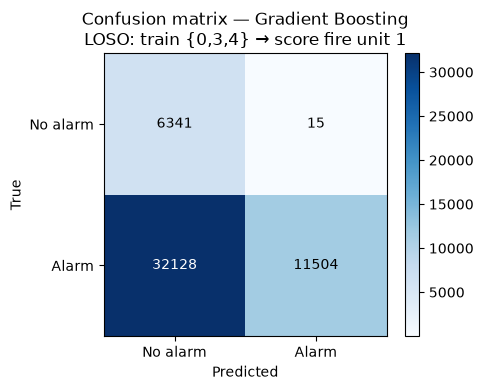

In [101]:
# Confusion matrix for Gradient Boosting on the held-out fire session (unit 1,
# the duplicate-fire unit) under LOSO — train on units {0,3,4}, score unit 1.
# GB is the one supervised model that shows non-trivial cross-session
# sensitivity (0.26), so it is the most informative single confusion matrix.
fire_mask = (groups == 1)
_X_fire = X[fire_mask]
_y_fire = y[fire_mask]
_gb_clone = clone(gb).fit(X[~fire_mask], y[~fire_mask])
_gb_preds = _gb_clone.predict(_X_fire)
cm = confusion_matrix(_y_fire, _gb_preds, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No alarm", "Alarm"]); ax.set_yticklabels(["No alarm", "Alarm"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — Gradient Boosting\nLOSO: train {0,3,4} → score fire unit 1")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

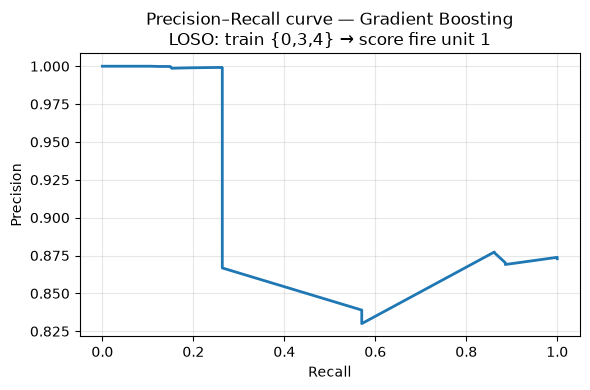

In [102]:
# Precision–Recall curve for Gradient Boosting on the same LOSO fire-session
# fold (train {0,3,4} → score unit 1). Uses the model's probability scores.
proba = _gb_clone.predict_proba(_X_fire)[:, 1]
prec, rec, _ = precision_recall_curve(_y_fire, proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, linewidth=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curve — Gradient Boosting\nLOSO: train {0,3,4} → score fire unit 1")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

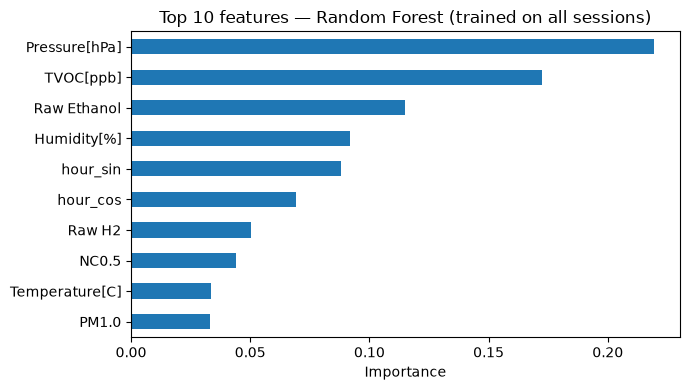

In [103]:
# Feature importances from the Random Forest (top 10). `rf` is a Pipeline
# (scaler + model), so the importances live on the final estimator.
imp = pd.Series(
    rf.named_steps["model"].feature_importances_, index=X.columns
).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
imp.head(10).plot(kind="barh", ax=ax)
ax.set_xlabel("Importance")
ax.set_title("Top 10 features — Random Forest (trained on all sessions)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Task 6 — Notebook summary

**Problem.** We trained a binary classifier to predict `Fire Alarm` (0/1) from
13 IoT sensor readings (temperature, humidity, TVOC, eCO2, raw H2, raw ethanol,
pressure, PM1.0/PM2.5, NC0.5/1.0/2.5, plus a cyclical time-of-day feature) on
the public Smoke Detection dataset. The business goal is to **reduce false
alarms** in firefighting systems while maintaining high recall.

**Critical data finding.** The dataset is *not* 62,630 independent samples.
It is a continuous recording from one sensor prototype: 62,625 of 62,629
row-to-row gaps are exactly 1 second, with only 4 gaps > 60s defining **5
recording sessions** — and two of those (sessions 1 and 2) are the *same
fire recorded twice* (identical row count, duration, and every gas/particulate
feature mean; sorted-TVOC correlation = 1.0000). After collapsing the
duplicate into one unit, there are **4 independent sessions**.

**Why this changes everything.** A random train/test split interleaves
adjacent seconds across the boundary, so tree models memorize the
near-duplicate readings and inflate F1 to **0.9998** — pure in-session
interpolation, not generalization. No leak-free whole-session split preserves
the 71/29 class balance (the duplicated fire alone is ~80% of all rows), so
we use **Leave-One-Session-Out (LOSO) CV**: train on 3 sessions, score the
held-out one, for every session.

**Evaluation model chosen.** Per-fold **sensitivity** (recall on alarm rows)
and **specificity** (TNR on no-alarm rows) instead of a single F1 — the two
regime metrics that matter for false-alarm reduction.

**Key performance results.** See `results_df`. With leakage removed:

- **The simple threshold rule transfers best.** On the held-out fire session
  it reaches sensitivity 0.57 with specificity 0.999 — it catches more than
  half the real alarms while staying quiet. That beats every ML model on the
  metric that matters for unseen fire sessions.
- **Random Forest collapses to 0.000 sensitivity on every fire session it
  didn't train on** — it misses 100% of alarms in unseen sessions — while
  staying quiet correctly on no-alarm session 0 (specificity 0.90).
- **Gradient Boosting** is the only ML model with non-trivial transfer
  (sensitivity 0.26 on the held-out fire unit), but it fires on nearly every
  row of the held-out no-alarm session 4 (specificity 0.000).
- **Isolation Forest** is bimodal and operationally useless — it either
  misses all alarms (sessions 0/1/4) or fires on everything (session 3).

**Honest conclusion.** The ML models learn **session-specific sensor
signatures**, not transferable fire signatures — they overfit to the
recording they were trained on. The interpretable two-feature rule, because
it cannot memorize, generalizes better across sessions. The earlier ~0.9998
was an artifact of row-level leakage. For real deployment, a model trained
on these sessions would need either (a) per-session calibration, or (b) a
larger, multi-session, multi-device dataset where "fire" is sampled
independently across environments. In the meantime, the simple rule is the
more trustworthy component to hand the P6/P7 agent.

**Limitations and challenges observed.**
- The dataset is effectively 4 independent recording sessions from one
  device — far below the diversity needed for a generalizable model. This is
  the binding constraint, not the algorithm.
- Class imbalance (71.5% alarm) is itself an artifact of one duplicated
  7-hour fire making up most of the data.
- The threshold rule's `T` and `V` thresholds are tuned on the full dataset
  and would not transfer to a different environment without re-tuning.
- Sensor drift over time is not represented; the model would need periodic
  retraining in production.
- Bias note: the dataset's "fire = 1" label was assigned by the prototype
  hardware, not by independent ground truth, so we inherit its definition of
  "fire signature".